In [1]:
import torch
from torch import nn

def corr2d(X, K):
    """compute 2D cross-correlation operation"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

In [2]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In [3]:
# 边缘检测
X = torch.ones((6, 8))
X[:, 2:6] = 0

K = torch.tensor([[1.0, -1.0]])
Y = corr2d(X, K)
corr2d(X.t(), K)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [4]:
conv2d = nn.Conv2d(1, 1, kernel_size=(1, 2), bias=False)

X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

epoch 2, loss 0.979
epoch 4, loss 0.168
epoch 6, loss 0.030
epoch 8, loss 0.006
epoch 10, loss 0.001


In [5]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 0.9926, -0.9972]])

## Ch6.3

In [6]:
import torch
from torch import nn

def comp_corr2d(conv2d, X):
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    return Y.reshape(Y.shape[2:])

conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_corr2d(conv2d, X).shape

torch.Size([8, 8])

In [7]:
conv2d = nn.Conv2d(1, 1, kernel_size=(3, 5), padding=(0, 1), stride = (3, 4))
comp_corr2d(conv2d, X).shape

torch.Size([2, 2])

## Ch6.4

In [8]:
def corr2d_multi_in(X, K):
    """compute 2D cross-correlation operation for multiple input channels"""
    return sum(corr2d(x, k) for x, k in zip(X, K))

In [9]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]], [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])
corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [10]:
def corr2d_multi_in_out(X, K):
    """compute 2D cross-correlation operation for multiple input and output channels"""
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [11]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

torch.Size([3, 2, 2, 2])

In [12]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

In [13]:
def corr2d_multi_in_out_1x1(X, K):
    """compute 2D cross-correlation operation for multiple input and output channels with 1x1 kernel"""
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

In [14]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))
Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6

## Ch6.5

In [15]:
# 验证图 6.5.1：2×2 最大汇聚窗口在 stride=1 时输出 2×2
X_pool = torch.arange(9, dtype=torch.float32).reshape(1, 1, 3, 3)

pool_stride_1 = nn.MaxPool2d(kernel_size=2, stride=1)
pool_default = nn.MaxPool2d(kernel_size=2)  # 默认 stride=kernel_size=2

Y_stride_1 = pool_stride_1(X_pool)
Y_default = pool_default(X_pool)

print('输入：\n', X_pool[0, 0])
print('stride=1，输出形状：', Y_stride_1.shape, '\n', Y_stride_1[0, 0])
print('默认 stride=2，输出形状：', Y_default.shape, '\n', Y_default[0, 0])

assert Y_stride_1.shape == (1, 1, 2, 2)
assert torch.equal(Y_stride_1[0, 0], torch.tensor([[4.0, 5.0], [7.0, 8.0]]))
assert Y_default.shape == (1, 1, 1, 1)
assert Y_default.item() == 4.0

输入：
 tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])
stride=1，输出形状： torch.Size([1, 1, 2, 2]) 
 tensor([[4., 5.],
        [7., 8.]])
默认 stride=2，输出形状： torch.Size([1, 1, 1, 1]) 
 tensor([[4.]])


## Ch6.6 LeNet

In [25]:
import torch
from torch import nn
from torch.utils import data
import torchvision
from torchvision import transforms

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

In [26]:
def get_dataloader_workers():
    return 4

def load_data_fashion_mnist(batch_size, resize = None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root = "../data", train = True, transform = trans, download = True
    )   
    mnist_test = torchvision.datasets.FashionMNIST(
        root = "../data", train = False, transform = trans, download = True
    )
    return(data.DataLoader(mnist_train, batch_size, shuffle = True, num_workers = get_dataloader_workers(), pin_memory=True),
           data.DataLoader(mnist_test, batch_size, shuffle = False, num_workers = get_dataloader_workers(), pin_memory=True))

In [27]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

In [24]:
# D2L 训练代码依赖的本地等价实现
import time
import matplotlib.pyplot as plt
from IPython import display

def try_gpu(i=0):
    """存在第 i 块 GPU 时返回该设备，否则返回 CPU。"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def accuracy(y_hat, y):
    """返回一个批次中预测正确的样本数。"""
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)
    return float((y_hat.to(y.dtype) == y).sum())

class Accumulator:
    """在多个批次之间累加若干数值。"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

class Timer:
    """记录多段代码的运行时间。"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        self.tik = time.perf_counter()

    def stop(self):
        self.times.append(time.perf_counter() - self.tik)
        return self.times[-1]

    def sum(self):
        return sum(self.times)

class Animator:
    """在 notebook 中逐步绘制训练曲线。"""
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None, fmts=('-', 'm--', 'g-.'),
                 figsize=(3.5, 2.5)):
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.legend = [] if legend is None else legend
        self.xlim = xlim
        self.ylim = ylim
        self.fmts = fmts
        self.X, self.Y = None, None
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def add(self, x, y):
        if not isinstance(y, (list, tuple)):
            y = [y]
        if not isinstance(x, (list, tuple)):
            x = [x] * len(y)
        if self.X is None:
            self.X = [[] for _ in range(len(y))]
            self.Y = [[] for _ in range(len(y))]
        for x_value, y_value, x_values, y_values in zip(x, y, self.X, self.Y):
            if x_value is not None and y_value is not None:
                x_values.append(x_value)
                y_values.append(y_value)
        self.ax.clear()
        for x_values, y_values, fmt in zip(self.X, self.Y, self.fmts):
            self.ax.plot(x_values, y_values, fmt)
        self.ax.set_xlabel(self.xlabel)
        self.ax.set_ylabel(self.ylabel)
        if self.xlim is not None:
            self.ax.set_xlim(self.xlim)
        if self.ylim is not None:
            self.ax.set_ylim(self.ylim)
        if self.legend:
            self.ax.legend(self.legend)
        self.ax.grid(True)
        display.display(self.fig)
        display.clear_output(wait=True)

In [28]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """Compute the accuracy for a model on a dataset using a GPU"""
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # Required for BERT fine-tuning (to be covered later)
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [29]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """Train a model with a GPU (defined in Chapter 6)."""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'train loss {train_l:.3f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(device)}')

train loss 0.467, train acc 0.823, test acc 0.819
170040.3 examples/sec on cuda:0


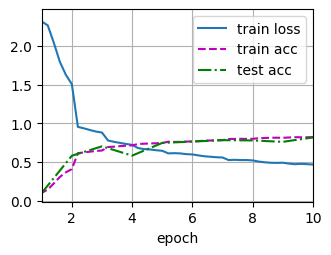

In [30]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())